# Polynomial regression 

The example belows uses a temperature-energy dataset in order to illustrate how to perform a non linear regression.

Workflow:
1. Preparation
    - Extract the dataset from the _power_demand_vs_temperature.csv_ 
    - Explore the dataset and check for missing values
    - Plot the distribution
    - Divide the dataset into train and test 
    - Create an evaluation function
2. First experiment
    - Create a linear model 
    - Train the model on X_train and y_train
    - Evaluate the model on X_test and y_test
    - Visualize the prediction of the model
3. Second experiment
    - Create a polynomial regression model with degree 2
    - Train the model on X_train and y_train
    - Evaluate the model on X_test and y_test
    - Visualize the prediction of the model
4. Third experiment
    - repeat the steps done in the second experiment but with degree 3
5. Third experiment
    - repeat the steps done in the second experiment but with degree 4
6. Compare the evaluation of each model


In [86]:
# Code source: Filippo Orazi 
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

random_state = 42 # this will be used to guarantee the repeatability of the experiment

## Dataset preparation

### Load the dataset from a `.csv` file
This cell allows full compatibility between execution in Google Colab and in local


In [87]:
# try:
#   import google.colab.files
#   IN_COLAB = True
# except:
#   IN_COLAB = False
# # from google.colab import files
# if IN_COLAB:
#     uploaded = files.upload()
path = "./power_demand_vs_temperature.csv"
df = pd.read_csv(path, index_col=0)

The file must be available in the same directory, or uploaded in the Colab environment in the execution of the previous cell


Set the date column as index

In [88]:
df.head()

,demand,temp
date,,
2015-01-01,1.736065,1.7
2015-01-02,1.831672,2.2
2015-01-03,1.714934,14.4
2015-01-04,1.628577,15.6
2015-01-05,2.045394,0.0


### Explore the dataset and check for missing values


In [89]:
df.describe()

,demand,temp
count,1096.000000,1096.000000
mean,1.831796,16.927737
std,0.329434,10.791581
min,1.316033,-15.000000
25%,1.581654,8.900000
50%,1.731479,18.900000
75%,2.024869,26.100000
max,2.804025,33.900000


In [90]:
print(f"The dataframe has {df.shape[0]-df.dropna().shape[0]} invalid rows")

The dataframe has 0 invalid rows


### Create X and y 

In [91]:
X = df["temp"]
y = df["demand"]

print(X.shape,y.shape)

(1096,) (1096,)


### Plot the distribution



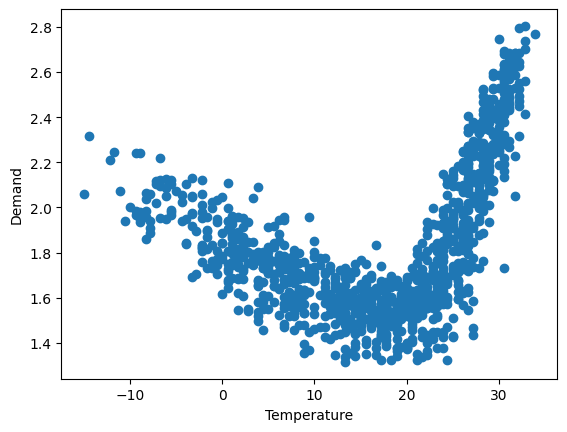

In [92]:
plt.scatter(X,y)
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.show()

### Divide the dataset in train and test splits

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    random_state=random_state,
    train_size=0.70
)
print(f"Training set and test set have {X_train.shape[0]} and {X_test.shape[0]} elements respectively")

Training set and test set have 767 and 329 elements respectively


### Create an evaluation function to compute, print and return the metrics: rmse r2 f-statistic and p-value

In [94]:
# Computation of F-statistic and p-value for the regression
# http://facweb.cs.depaul.edu/sjost/csc423/documents/f-test-reg.htm
from scipy.stats import f
def evaluation_function(y_pred, y_true):
    r2 = r2_score(y_pred=y_pred, y_true=y_true)
    mse = mean_squared_error(y_pred=y_pred, y_true=y_true)

    
    for k,v in zip(
        ["MSE score", "r2 score"],
        [mse, r2]):
        print(f"{k} \t {round(v,4)}")



## First experiment
Create a linear model 

Train the model on X_train and y_train 

Evaluate the model on X_test and y_test


In [95]:
linear_m = LinearRegression()
linear_m.fit(X_train.values.reshape(-1,1), y_train)
y_pred_linear_model = linear_m.predict(X_test.values.reshape(-1,1))
evaluation_function(y_pred_linear_model, y_test)

MSE score 	 0.1017
r2 score 	 0.1681


#### Visualize the prediction of the model 

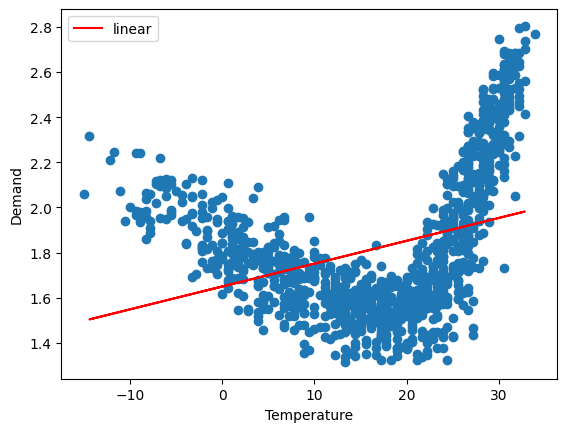

In [111]:
plt.scatter(X,y)
plt.plot(X_test, y_pred_linear_model, label="linear", c="r")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.legend()
plt.show()

## Second experiment - Polynomial regression
We can clearly see that the linear regression model cannot really approximate the data distribution.

We can now try with a non linear regression model:
1. Use the sklearn fucntion _PolynomialFeature_ to create a new array of features. Set _degree=2_ and _include_bias=False_
2. Train a Linear regression model with the new features
3. Evaluate the model 
4. Visualize the predicted values of the model

#### Polynomial degree = 2

In [97]:
pol = PolynomialFeatures(degree=2, include_bias=False)
# Transform the old dataset in a more dimensional one
X_train_2 = pol.fit_transform(X_train.values.reshape(-1,1))
non_linear2_m = LinearRegression()
non_linear2_m.fit(X_train_2, y_train)


LinearRegression()

In [106]:
X_test_2 = pol.fit_transform(X_test.values.reshape(-1,1))
y_pred_non_linear2_model = non_linear2_m.predict(X_test_2)
evaluation_function(y_pred_non_linear2_model.reshape(-1,1), y_test)

MSE score 	 0.0335
r2 score 	 0.7262


/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_98217/478774689.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_test[ind], y_pred_non_linear2_model[ind], label="poly", c="r")


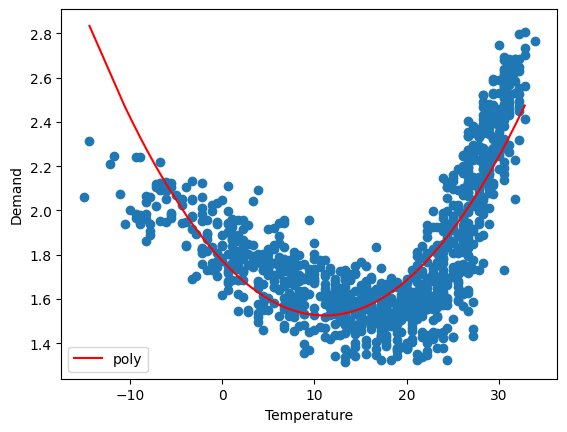

In [125]:
plt.scatter(X,y)
# plt.scatter(X_test, y_pred_non_linear2_model, marker='o', label="poly", c="r")
ind = X_test.argsort()
plt.plot(X_test[ind], y_pred_non_linear2_model[ind], label="poly", c="r")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.legend()
plt.show() 

## Third experiment

#### Polynomial degree = 3

In [ ]:
pol = PolynomialFeatures(degree=3, include_bias=False)
# Transform the old dataset in a more dimensional one
X_train_3 = pol.fit_transform(X_train.values.reshape(-1,1))
non_linear3_m = LinearRegression()
non_linear3_m.fit(X_train_3, y_train)


LinearRegression()

In [127]:
X_test_3 = pol.fit_transform(X_test.values.reshape(-1,1))
y_pred_non_linear3_model = non_linear3_m.predict(X_test_3)
evaluation_function(y_pred_non_linear3_model.reshape(-1,1), y_test)

MSE score 	 0.0217
r2 score 	 0.822


/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_98217/3167776011.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_test[ind], y_pred_non_linear3_model[ind], label="poly", c="r")


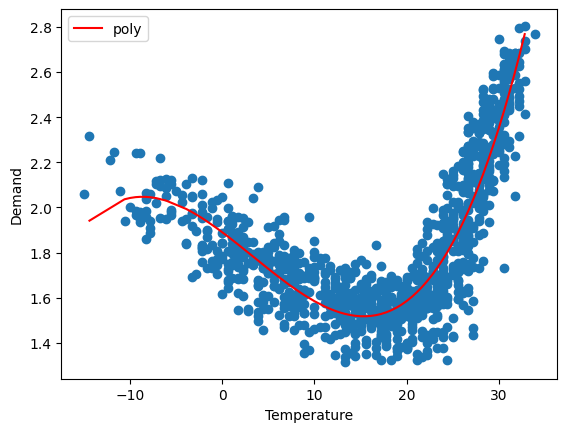

In [128]:
plt.scatter(X,y)
ind = X_test.argsort()
plt.plot(X_test[ind], y_pred_non_linear3_model[ind], label="poly", c="r")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.legend()
plt.show() 

## Fourth experiment
### Polynomial degree = 4

In [129]:
pol = PolynomialFeatures(degree=4, include_bias=False)
# Transform the old dataset in a more dimensional one
X_train_4 = pol.fit_transform(X_train.values.reshape(-1,1))
non_linear4_m = LinearRegression()
non_linear4_m.fit(X_train_4, y_train)

LinearRegression()

In [130]:
X_test_4 = pol.fit_transform(X_test.values.reshape(-1,1))
y_pred_non_linear4_model = non_linear4_m.predict(X_test_4)
evaluation_function(y_pred_non_linear4_model.reshape(-1,1), y_test)

MSE score 	 0.0213
r2 score 	 0.8254


/var/folders/n9/r8x6svc56fjb_2b7zb4tztr80000gn/T/ipykernel_98217/600898634.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.plot(X_test[ind], y_pred_non_linear4_model[ind], label="poly", c="r")


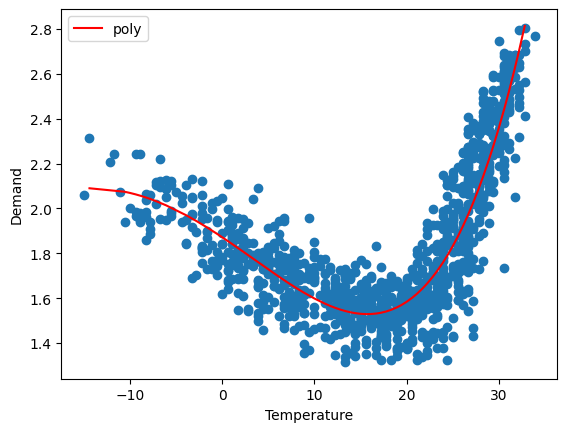

In [131]:
plt.scatter(X,y)
ind = X_test.argsort()
plt.plot(X_test[ind], y_pred_non_linear4_model[ind], label="poly", c="r")
plt.xlabel("Temperature")
plt.ylabel("Demand")
plt.legend()
plt.show() 

## Compare the performance of the four models

In [133]:
for k,v in zip(["linear", "polynomial d = 2", "polynomial d = 3", "polynomial d = 4"],
               [y_pred_linear_model, y_pred_non_linear2_model, y_pred_non_linear3_model, y_pred_non_linear4_model]):
    evaluation_function(v, y_test)
    print("-"*30)

MSE score 	 0.1017
r2 score 	 0.1681
------------------------------
MSE score 	 0.0335
r2 score 	 0.7262
------------------------------
MSE score 	 0.0217
r2 score 	 0.822
------------------------------
MSE score 	 0.0213
r2 score 	 0.8254
------------------------------
